In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

### Count Job Titles by each Country

In [2]:
df_job_country_salary = df.pivot_table(
               index='job_country', 
               columns='job_title_short', 
               values='salary_year_avg',  
               aggfunc='median')

top_countries = df['job_country'].value_counts().head(6).index

df_job_country_salary = df_job_country_salary.loc[top_countries]

df_job_country_salary

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
United States,90000.0,116100.0,90000.0,125000.0,130000.0,150000.0,110000.0,150000.0,155000.0,130000.0
India,64800.0,NaN,100500.0,147500.0,114008.0,79200.0,111175.0,147500.0,149653.0,79200.0
United Kingdom,56700.0,NaN,87750.0,110000.0,105300.0,149653.0,111175.0,147500.0,157500.0,89100.0
France,89100.0,105968.0,69175.0,98301.5,88128.0,80850.0,111175.0,147500.0,157500.0,142500.0
Germany,89100.0,89100.0,103750.0,147500.0,131560.0,89100.0,111175.0,147500.0,157500.0,84975.0
Spain,86400.0,89100.0,91977.0,133000.0,88128.0,101029.0,111175.0,147500.0,157500.0,77050.0


### Filter and plot the pivot table

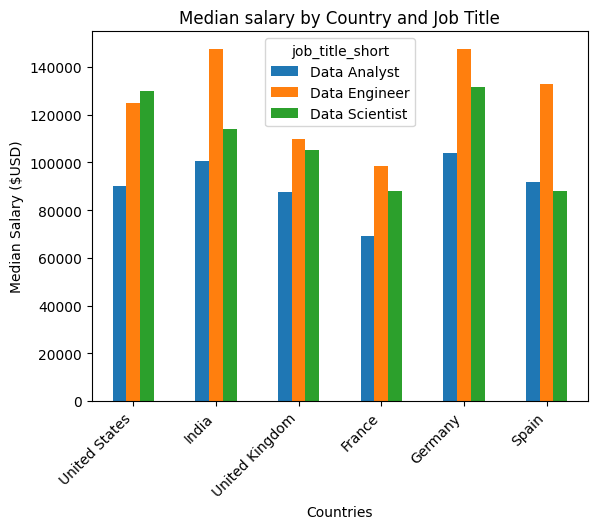

In [6]:
jobs = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_job_country_salary = df_job_country_salary[jobs]

df_job_country_salary.plot(kind='bar')

plt.title('Median salary by Country and Job Title')

plt.ylabel('Median Salary ($USD)')
plt.xlabel('Countries')

plt.xticks(rotation= 45, ha='right')
plt.show()


### Sort DataFrame by the 'Total' row

In [7]:
df_job_country_salary.loc['Total'] = df_job_country_salary.sum()

In [8]:
# Sort the DataFrame by the 'Total' row in descending order
df_job_country_salary = df_job_country_salary[df_job_country_salary.loc['Total'].sort_values(ascending=False).index]
df_job_country_salary

job_title_short,Data Engineer,Data Scientist,Data Analyst
job_country,,,
United States,125000.0,130000.0,90000.0
India,147500.0,114008.0,100500.0
United Kingdom,110000.0,105300.0,87750.0
France,98301.5,88128.0,69175.0
Germany,147500.0,131560.0,103750.0
Spain,133000.0,88128.0,91977.0
Total,761301.5,657124.0,543152.0


In [9]:
df_job_country_salary.iloc[:, :5]

job_title_short,Data Engineer,Data Scientist,Data Analyst
job_country,,,
United States,125000.0,130000.0,90000.0
India,147500.0,114008.0,100500.0
United Kingdom,110000.0,105300.0,87750.0
France,98301.5,88128.0,69175.0
Germany,147500.0,131560.0,103750.0
Spain,133000.0,88128.0,91977.0
Total,761301.5,657124.0,543152.0
